In [317]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math
drivers = pd.read_csv('drivers.csv')
passengers = pd.read_csv('passengers.csv')
taxi_2 = pd.read_csv('taxi_2.csv')

#Объединим таблицы drivers и passengers с помощью merge()
#И склеим ретью таблицу taxi_2 с помощью pd.concat()
taxi = pd.concat([drivers.merge(passengers, on='journey_id'), taxi_2]).reset_index()
taxi

,index,journey_id,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score,user_id,start_type,start_lat,start_lon,source,driver_score
0,0,23a1406fc6a11d866e3c82f22eed4d4c,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0
1,1,dd2af4715d0dc16eded53afc0e243577,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN
2,2,dd91e131888064bf7df3ce08f3d4b4ad,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN
3,3,dd2af4715d0dc16eded53afc0e2466d0,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN
4,4,85b7eabcf5d84e42dc7629b7d27781af,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23106,11551,4a18ea5737ce0ffecaf20b305a0e2c86,d665fb9f75ef5d9cd0fd89479380ba78,16cbe35db7fff70fbc8251b4cda9fdc9,executive,2010-07-31 13:15:00,2010-07-31 13:27:00,"-12,08352661","-77,05044556",drop off,"-12,08973527","-77,04787016",2010-07-31 13:15:00,5.0,8998bb370b5f0cec43a373adebba0c72,reserved,"-12,08974075","-77,04699707",iPhone,5.0
23107,11552,f1e4317f2c17991dd90d1cd17ae0d399,17c21284245ff240c7212732991c2373,716a697375634f32a06d692b0448f13d,executive,2010-10-02 05:26:00,2010-10-02 05:56:00,"-12,07776001","-77,05623798",drop off,"-12,10639693","-77,04028948",2010-10-02 05:39:00,5.0,5f8a6ffef0ea5df78a8ee890267b60ec,asap,"-12,09253011","-77,02875271",Android,NaN
23108,11553,1e44c0fd0a266c3719ff30410b257bce,4851ee4c867c9b49b909c1adb76c31e9,4851ee4c867c9b49b909c1adb76c538e,executive,2010-09-21 09:56:00,2010-09-21 10:18:00,"-12,10529838","-77,04735249",drop off,"-12,12605017","-77,01882491",2010-09-21 10:05:00,0.0,c0ffb6f6cd801004dd8609c12277c2d1,asap,"-12,1275637","-77,02642288",Android,0.0
23109,11554,7073883383b89ad289e864022150cdd7,56f59b58bcbbd1cdabc3652e713134c2,924d4f0e7554566623e8ebb3904a7b0c,executive,2010-04-29 04:30:00,2010-04-29 05:11:00,"-12,09909987","-77,03475013",drop off,"-12,0710933","-77,09855131",2010-04-29 04:23:00,5.0,c0ffb6f6cd801004dd8609c12277c2d1,reserved,"-12,019468","-77,1077669",Android,NaN


In [318]:
#Проверим в есть ли пропущенные занчения в таблице и как много. Нужно найти колонку, где пропущенных
#значений наибольшее колличество.
taxi.isna().sum().idxmax()


'driver_score'

In [319]:
#Перейдем к анализу этих платформ. Определим долю заказов, сделанных с той или иной платформы. 
# У какой платформы эта доля самая большая? 
#В ответе укажим значение наибольшей доли заказов в %, округлённое до целого.

q = round(taxi.source.value_counts(normalize=True) * 100, 2)
q



source
iPhone     42.37
web        33.20
Android    21.35
iPad        2.48
Wap         0.59
Name: proportion, dtype: float64

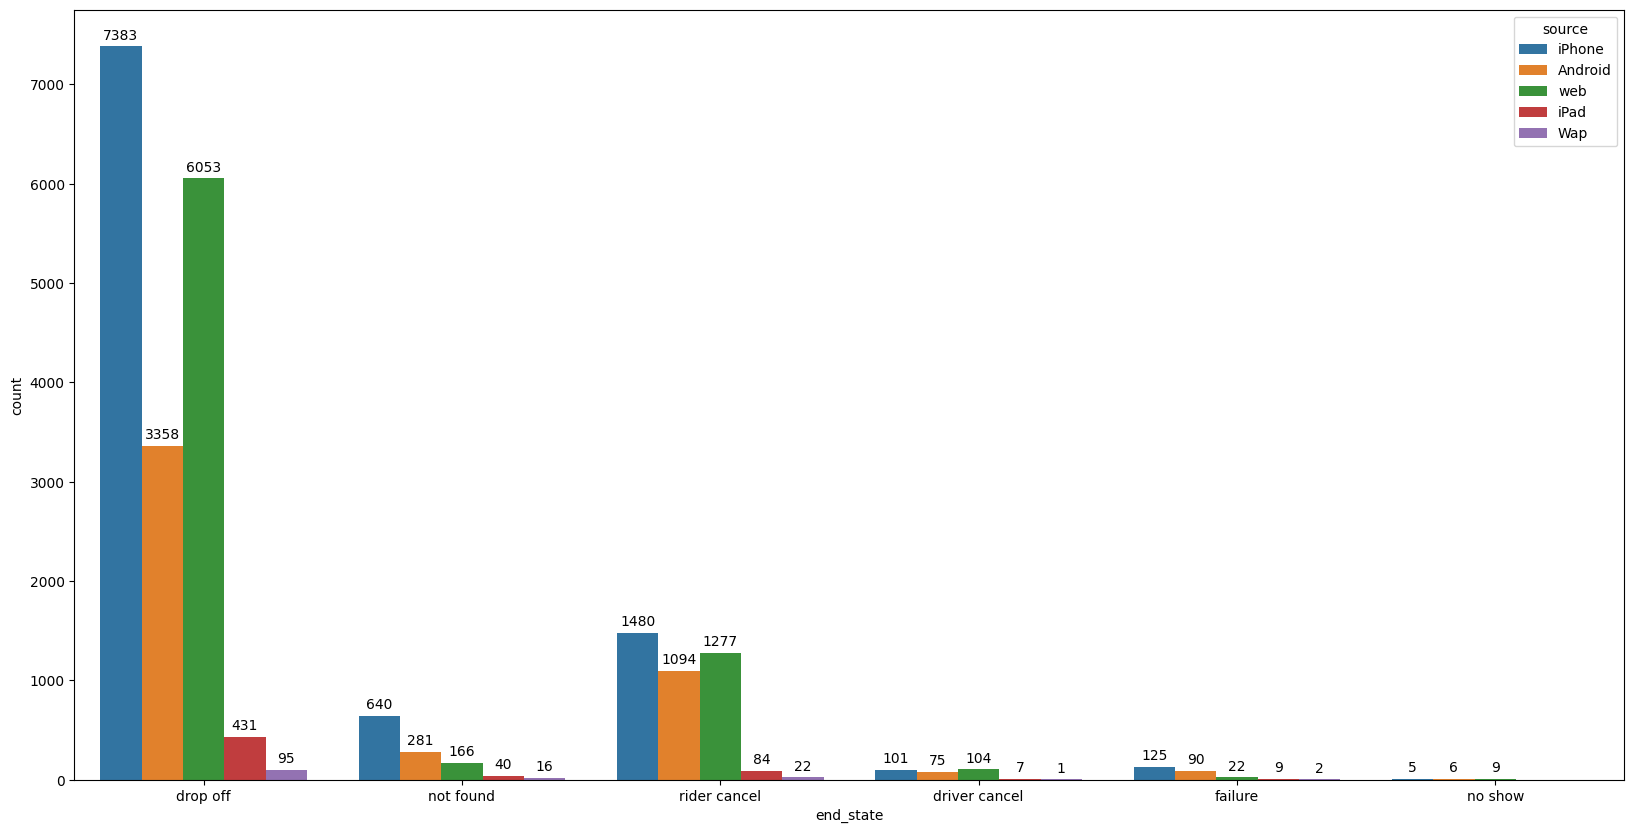

In [320]:
#Более детально проанализируем распределение заказов по платформам. 
# С помощью функции sns.countplot и параметра 
# hue визуализируем распределение переменной end_state (итоговое состояние заказа) в 
# разбивке по платформам (см.колонку source).

plt.figure(figsize=(20,10))
taxi = taxi.reset_index(drop=True)
ax = sns.countplot(data=taxi, x='end_state', hue='source')
for container in ax.containers:
    ax.bar_label(container, padding=3)


In [ ]:
#Больше всего заказов со статусом drop off совершено с платформы iPhone
#На Android количество отмененных поездок (rider cancel) меньше, чем на iPhone
#Наибольшая разница между количеством drop off и rider cancel наблюдается для платформы iPhone


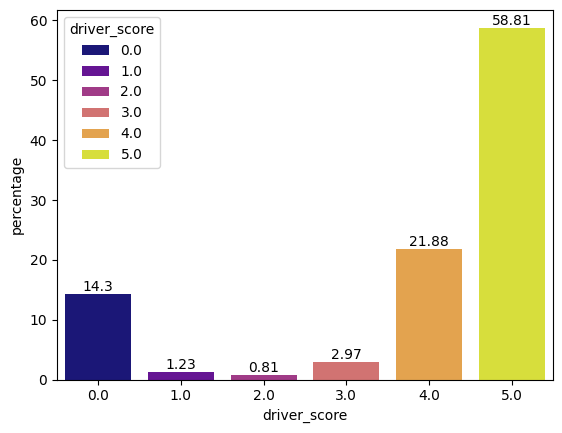

In [321]:
#С платформами разобрались. Теперь давайте перейдем к анализу оценок, которые ставят пассажиры 
# водителям и водители пассажирам.
#Проверим, как распределены оценки водителей 
# (см.колонку driver_score).

driver_score_counts = round(taxi.driver_score.value_counts(normalize=True) * 100,2 )\
    .reset_index()\
    .rename(columns={'proportion': 'percentage'})\
    .sort_values('driver_score')
ax = sns.barplot(driver_score_counts, x='driver_score', y='percentage', hue = 'driver_score', palette='plasma')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

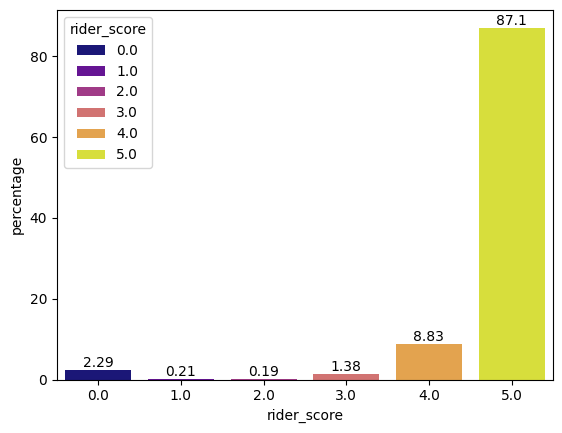

In [ ]:
#Сейчас повторим процесс и проанализируем оценки водителями пассажиров 
# (см.колонку rider_score). 
# Сравним распределение этих оценок с распределением оценок водителей.

rider_score_counts = round(taxi.rider_score.value_counts(normalize=True) * 100,2 )\
    .reset_index()\
    .rename(columns={'proportion': 'percentage'})\
    .sort_values('rider_score')
ax = sns.barplot(rider_score_counts, x='rider_score', y='percentage', hue = 'rider_score', palette='plasma')
for container in ax.containers:
    ax.bar_label(container)
plt.show()


In [192]:
#Более чем в 80% случаев водители поставили клиентам 5 звездочек
#Водители ставят меньше оценок 0, чем клиенты


In [322]:
#Теперь перейдем к анализу временных данных. Но перед этим приведем столбцы start_at, end_at, arrived_at к формату даты и времени, 
# используя pd.to_datetime. Отфильтруем данные и оставим наблюдения со статусами заказа "asap" и "reserved" (см.колонку start_type). 
# Результат сохраним в тот же датафрейм taxi

taxi[['start_at', 'end_at', 'arrived_at']] = taxi[['start_at', 'end_at', 'arrived_at']].apply(pd.to_datetime)


In [323]:
#Начнем анализировать время подачи машины — долго ли пассажирам приходится ждать такси. 
# Для этого создадим новую колонку wait_time, в которой будет храниться разница между временем подачи машины (см.колонку arrived_at) и 
# временем заказа (см.колонку start_at). Определим медианное время подачи машины, в минутах. 
# Ответ в формате целого числа

taxi['wait_time'] = ((taxi['arrived_at'] - taxi['start_at']).dt.total_seconds() / 60)
taxi['wait_time'].median()

np.float64(5.0)

In [324]:
#Если клиент сделал заказ к определенному времени (start_type == 'reserved'), но ему пришлось ждать машину (wait_time > 0), 
# значит, водитель опоздал. Определим id водителя, который чаще всего опаздывал на заказы, заранее сделанные клиентами.
taxi['wait_time'] = taxi['wait_time'].fillna(0)
taxi.query('start_type == "reserved" and wait_time > 0').groupby('driver_id')['driver_id'].value_counts().reset_index().sort_values('count', ascending=False)


,driver_id,count
24,406921adcca37705ef527b4246c0cfea,67
86,d665fb9f75ef5d9cd0fd89479380ba78,59
93,ec84a73745199ff840ecafcb924383ad,57
29,56f59b58bcbbd1cdabc3652e713134c2,51
77,c814db2127582cf95dea1f74f43127c2,45
...,...,...
88,d7bf644eb441cda6127f91addebb85c4,1
71,b68895736389f2949faa8c73555b81ac,1
51,8cb98e46b27af1e6fca8768a2a6329f3,1
16,389bfa333ba8fa7281dd5f0e1b57c0c1,1


In [325]:
#Подумаем, что может влиять на число опозданий водителя из прошлого задания. 
#Проанализируем имеющиеся у вас данные.

journeys = taxi.groupby('driver_id', as_index = False)\
    .agg({'journey_id':'nunique'})\
    .sort_values('journey_id', ascending = False)\
    .rename(columns = {'journey_id':'journey_num'})

journeys.head()

delays = (taxi.query('start_type == "reserved" and wait_time > 5') # Если выполняете задание не в JupyterHub нашего курса, то может возникнуть ошибка `ValueError: unknown type object`, тогда в методе query задайте параметр engine='python'
    .groupby('driver_id', as_index = False)
    .agg({'journey_id':'nunique'})
    .sort_values('journey_id', ascending = False)
    .rename(columns = {'journey_id':'delay_num'}))

delays.head()


journeys_delays = journeys.merge(delays, on = 'driver_id')
journeys_delays['late_score'] = round(100 * journeys_delays.delay_num / journeys_delays.journey_num)
journeys_delays.sort_values('delay_num', ascending = False).head()

journeys_delays.late_score.describe()

count    90.000000
mean      6.522222
std       8.250608
min       1.000000
25%       2.000000
50%       3.000000
75%       7.000000
max      50.000000
Name: late_score, dtype: float64

In [ ]:
#На колличество опозданий ВЛИЯЛО Число взятых заказов
#НЕ ВЛИЯЛО Непунктуальность водителя (доля опозданий от всех его поездок у этого водителя больше, 
#чем соответствующие доли у остальных опаздывающих водителей)



In [326]:
#С опозданиями разобрались. Теперь расширим наши данные новыми 
# признаками: добавим столбец month, где будет храниться номер 
# месяца, 
# в котором был сделан заказ (см.колонку start_at), и столбец 
# weekday – название дня недели.

taxi['month'] = taxi['start_at'].dt.month_name()
taxi['month']
taxi['weekday'] = taxi['start_at'].dt.day_name()
taxi['weekday']



0         Tuesday
1         Tuesday
2          Monday
3         Tuesday
4        Saturday
           ...   
23106    Saturday
23107    Saturday
23108     Tuesday
23109    Thursday
23110     Tuesday
Name: weekday, Length: 23111, dtype: str

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_56485/2722783910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=taxi, x=taxi['month'], palette='plasma', order=order_month)


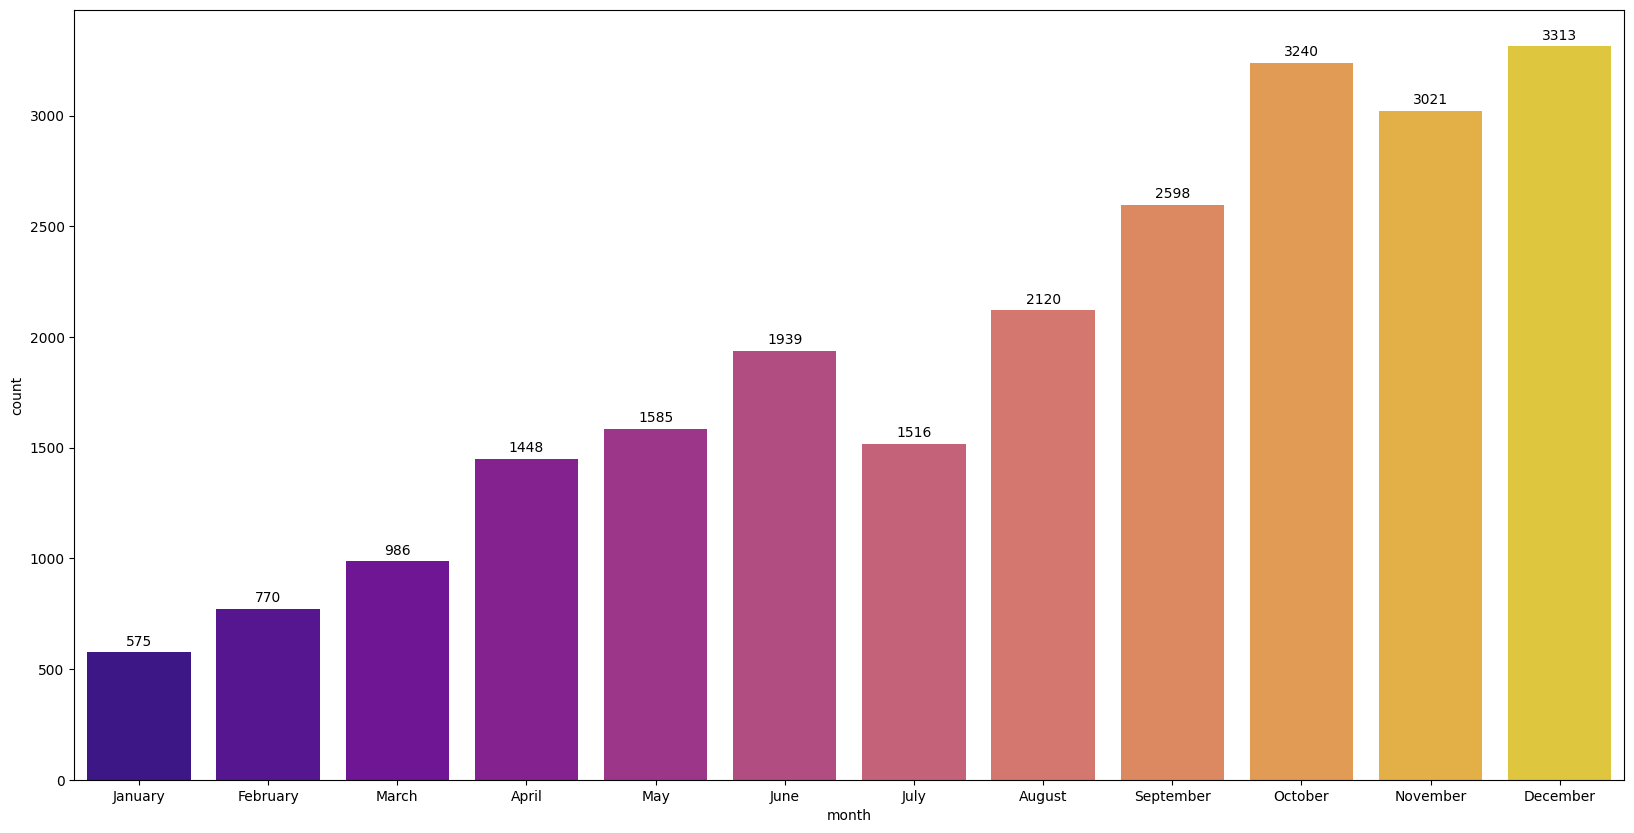

In [327]:
#Изучим, есть ли сезонные колебания в заказах такси. 
# Построим график количества заказов по месяцам и определите месяц с наименьшим количеством заказов летом.
order_month = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(20,10))
ax = sns.countplot(data=taxi, x=taxi['month'], palette='plasma', order=order_month)
for container in ax.containers:
    ax.bar_label(container, padding=3)





/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_56485/48925629.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=taxi, x=taxi['weekday'], palette='plasma', order=order_week)


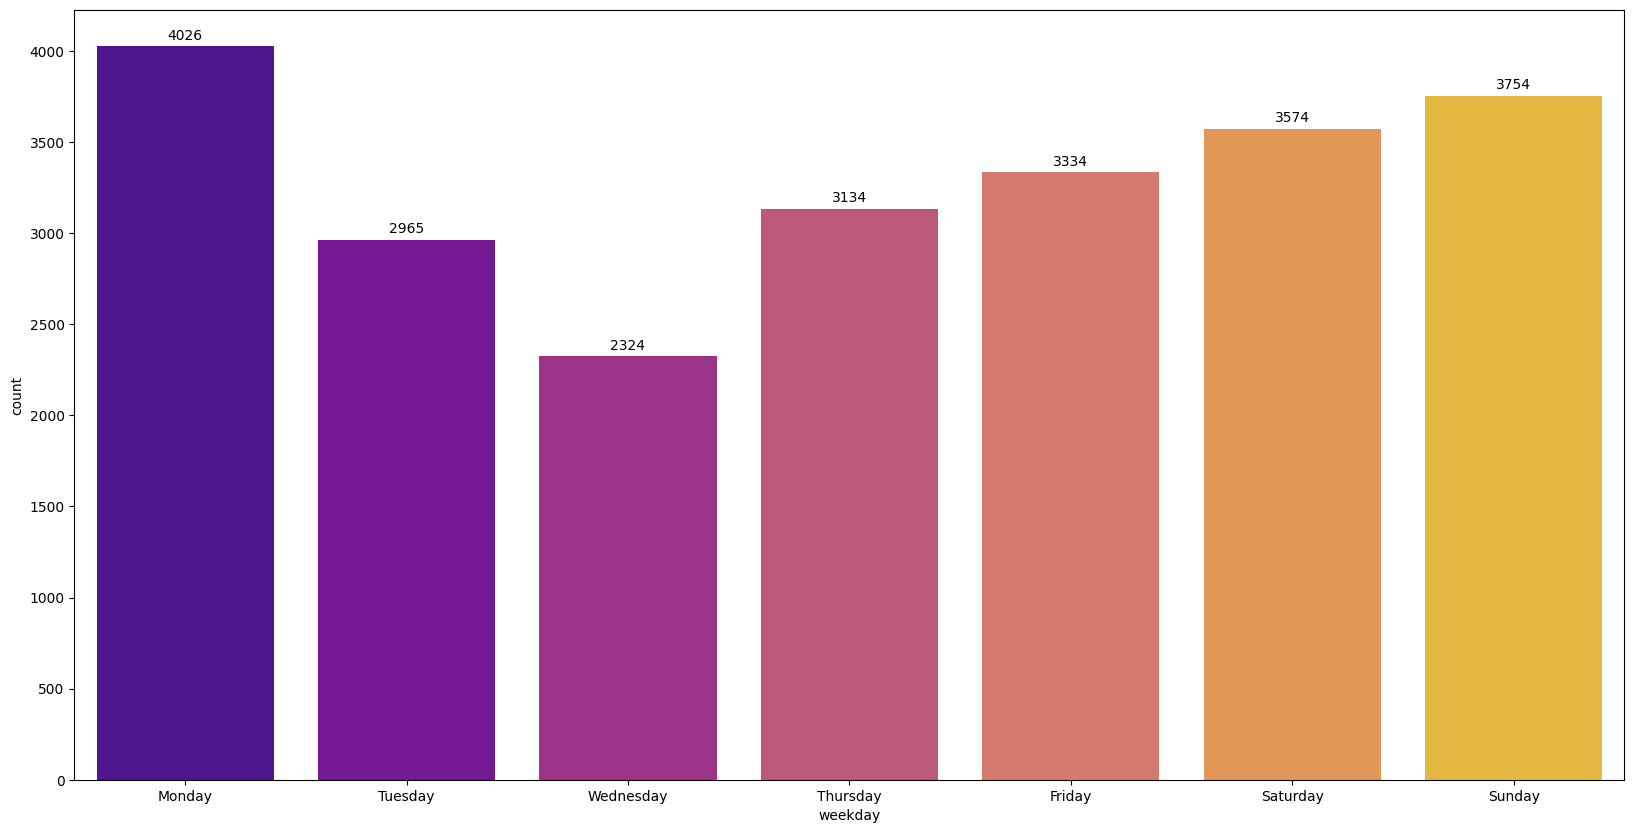

In [328]:
#Сезонность бывает не только внутри года, но и внутри недели. 
# Определим, в какой день недели поступает меньше всего заказов. 
# Укажим то название, которое написано в самом датафрейме.

order_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(20,10))
ax = sns.countplot(data=taxi, x=taxi['weekday'], palette='plasma', order=order_week)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()



/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_56485/3366988525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(mau, x='month', y='user_id', palette='plasma')


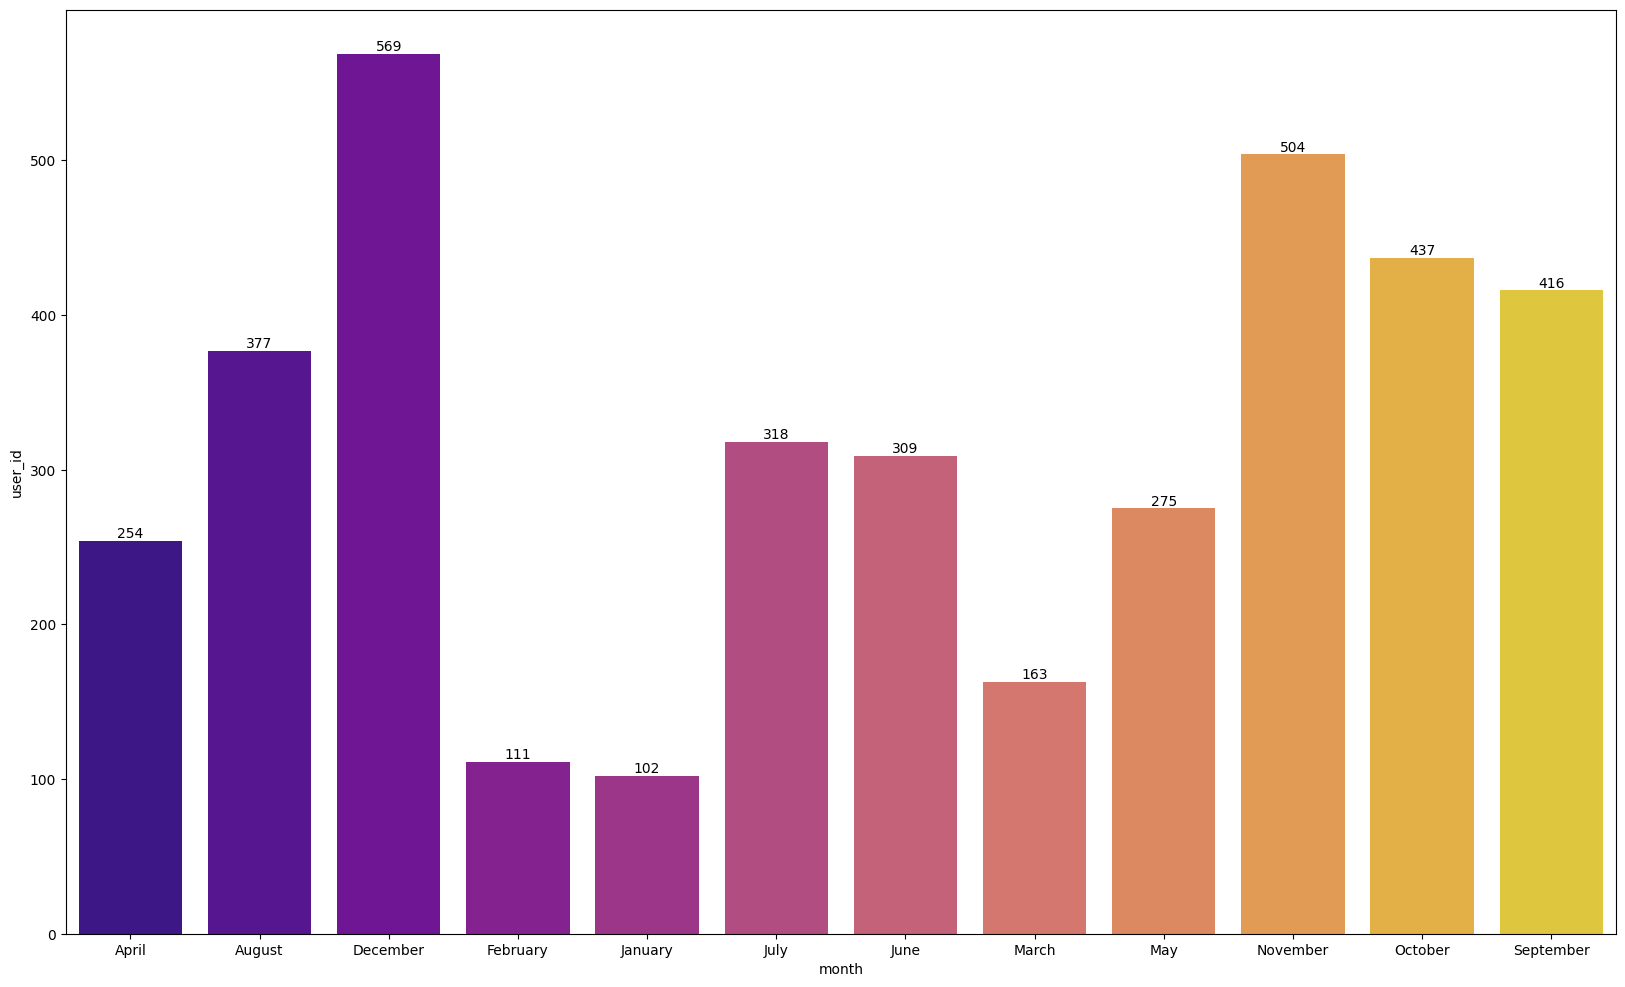

In [150]:
#Познакомимся с часто используемыми метриками, показывающими число активных пользователей за определённый период:
#DAU (daily active users) – число уникальных активных пользователей за день
#WAU (weekly active users) – число уникальных активных пользователей за неделю
#MAU (monthly active users) – число уникальных активных пользователей за месяц
#Активные пользователи – те, кто воспользовался приложением и сделал хотя бы один заказ за выбранный промежуток времени.
#Посчитайте метрику MAU, постройте её график и выберите одно или несколько верных утверждений
plt.figure(figsize=(20,12))
mau = taxi.groupby('month', as_index=False).user_id.nunique()
ax = sns.barplot(mau, x='month', y='user_id', palette='plasma')
for container in ax.containers:
    ax.bar_label(container)
plt.show()



In [329]:
#Пространственная аналитика (Геоданные): 
# Использовать start_lat/start_lon и end_lat/end_lon, 
# чтобы рассчитать дистанцию каждой поездки 
# (ищи формулу Гаверсинуса для Python). 
# Цель: Понять, зависит ли вероятность отмены заказа от 
# предполагаемой дальности поездки.

taxi[['start_lat', 'start_lon', 'end_lat', 'end_lon']] = taxi[['start_lat', 'start_lon', 'end_lat', 'end_lon']].replace(',', '.', regex=True).astype(float)
taxi.info()

<class 'pandas.DataFrame'>
RangeIndex: 23111 entries, 0 to 23110
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             23111 non-null  int64         
 1   journey_id        23111 non-null  str           
 2   driver_id         19726 non-null  str           
 3   taxi_id           19726 non-null  str           
 4   icon              23111 non-null  str           
 5   start_at          23111 non-null  datetime64[us]
 6   end_at            22835 non-null  datetime64[us]
 7   end_lat           23111 non-null  float64       
 8   end_lon           23111 non-null  float64       
 9   end_state         23099 non-null  str           
 10  driver_start_lat  19621 non-null  str           
 11  driver_start_lon  19621 non-null  str           
 12  arrived_at        17716 non-null  datetime64[us]
 13  rider_score       15390 non-null  float64       
 14  user_id           23111 non-null 

(0.0, 50.0)

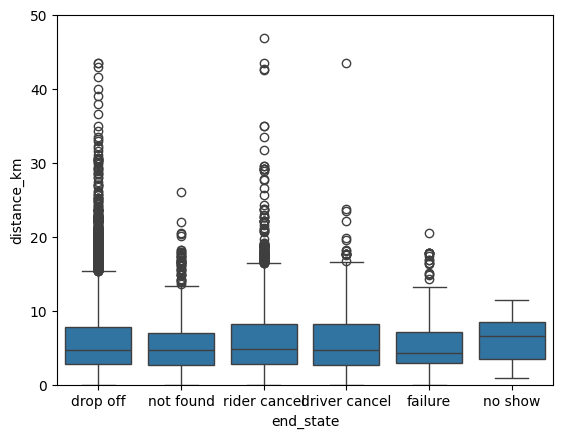

In [332]:
def haversine_vectorized(start_lat, end_lat, start_lon, end_lon):
    # Шаг 0: Перевод координат из градусов в радианы
    start_lat, start_lon, end_lat, end_lon = map(np.radians, [start_lat, start_lon, end_lat, end_lon])

    dlat = end_lat - start_lat 
    dlon = end_lon - start_lon

    a = np.sin(dlat/2) ** 2 + np.cos(start_lat) * np.cos(end_lat) * np.sin(dlon/2) ** 2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))
    R = 6371
    d = R * c
    
    return d


taxi['distance_km'] = haversine_vectorized(taxi["start_lat"],taxi["end_lat"], taxi["start_lon"], taxi["end_lon"])
taxi[['start_lat', 'end_lat', 'start_lon', 'end_lon', 'distance_km']]
taxi.groupby('end_state')['distance_km'].value_counts()
taxi.groupby('end_state')['journey_id'].count()
median_km = taxi.groupby('end_state').agg({'distance_km': 'median'}).reset_index()

sns.boxplot(taxi, x='end_state', y='distance_km')
plt.ylim(0, 50)

In [ ]:
taxi.groupby('start_type')['start_type'].count()

start_type
asap        14865
delayed        20
reserved     8226
Name: start_type, dtype: int64

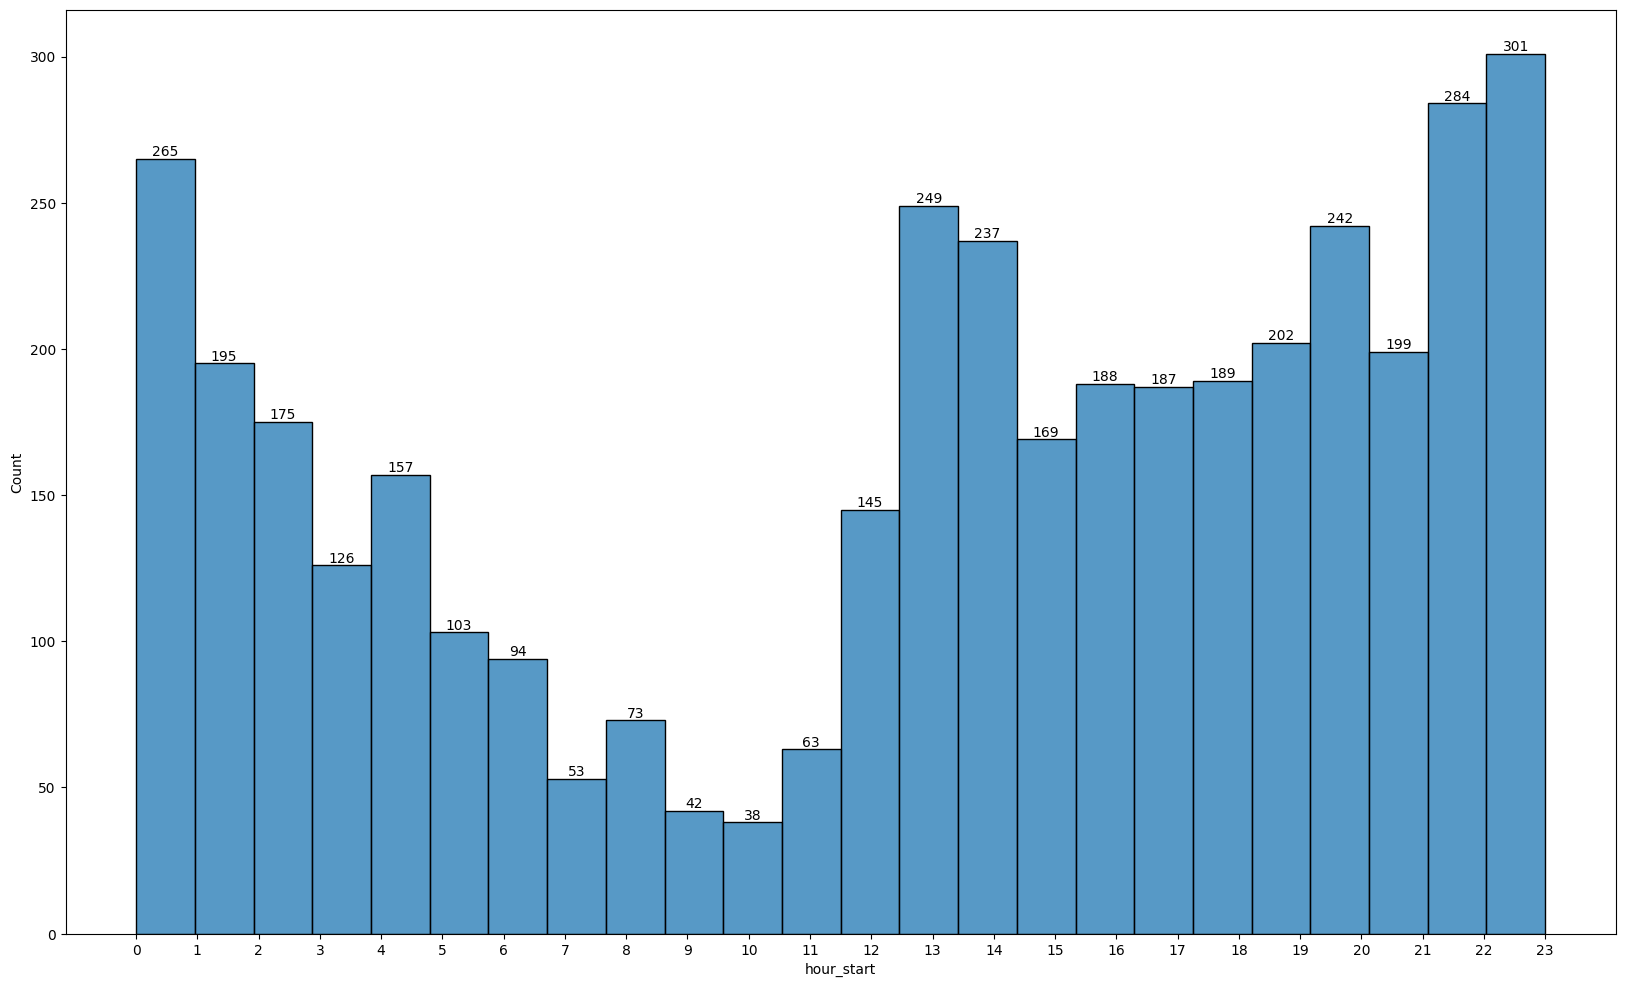

In [247]:
taxi['hour_start'] = pd.to_datetime(taxi['start_at']).dt.hour
canceled_hours = taxi.query('end_state=="rider cancel"')\
    .groupby('hour_start', as_index=False)['journey_id'].count()
plt.figure(figsize=(20,12))
ax = sns.histplot(data=taxi.query('end_state == "rider cancel"'), x='hour_start', bins=24)
plt.xticks(np.arange(0,24,1))
ax.bar_label(ax.containers[0])
plt.show()

cancel_rate = round(taxi.query('end_state == "rider cancel"').groupby('hour_start')['journey_id'].size() / taxi.groupby('hour_start')['journey_id'].size() * 100, 2).reset_index()



[Text(0, 0, '19.46'),
 Text(0, 0, '15.34'),
 Text(0, 0, '16.63'),
 Text(0, 0, '14.25'),
 Text(0, 0, '18.94'),
 Text(0, 0, '16.35'),
 Text(0, 0, '19.03'),
 Text(0, 0, '14.68'),
 Text(0, 0, '22.05'),
 Text(0, 0, '17'),
 Text(0, 0, '16.1'),
 Text(0, 0, '14.09'),
 Text(0, 0, '13.24'),
 Text(0, 0, '12.4'),
 Text(0, 0, '17.62'),
 Text(0, 0, '15.32'),
 Text(0, 0, '20.11'),
 Text(0, 0, '18.02'),
 Text(0, 0, '21.7'),
 Text(0, 0, '20.32'),
 Text(0, 0, '20.93'),
 Text(0, 0, '17.85'),
 Text(0, 0, '18.97'),
 Text(0, 0, '16.63')]

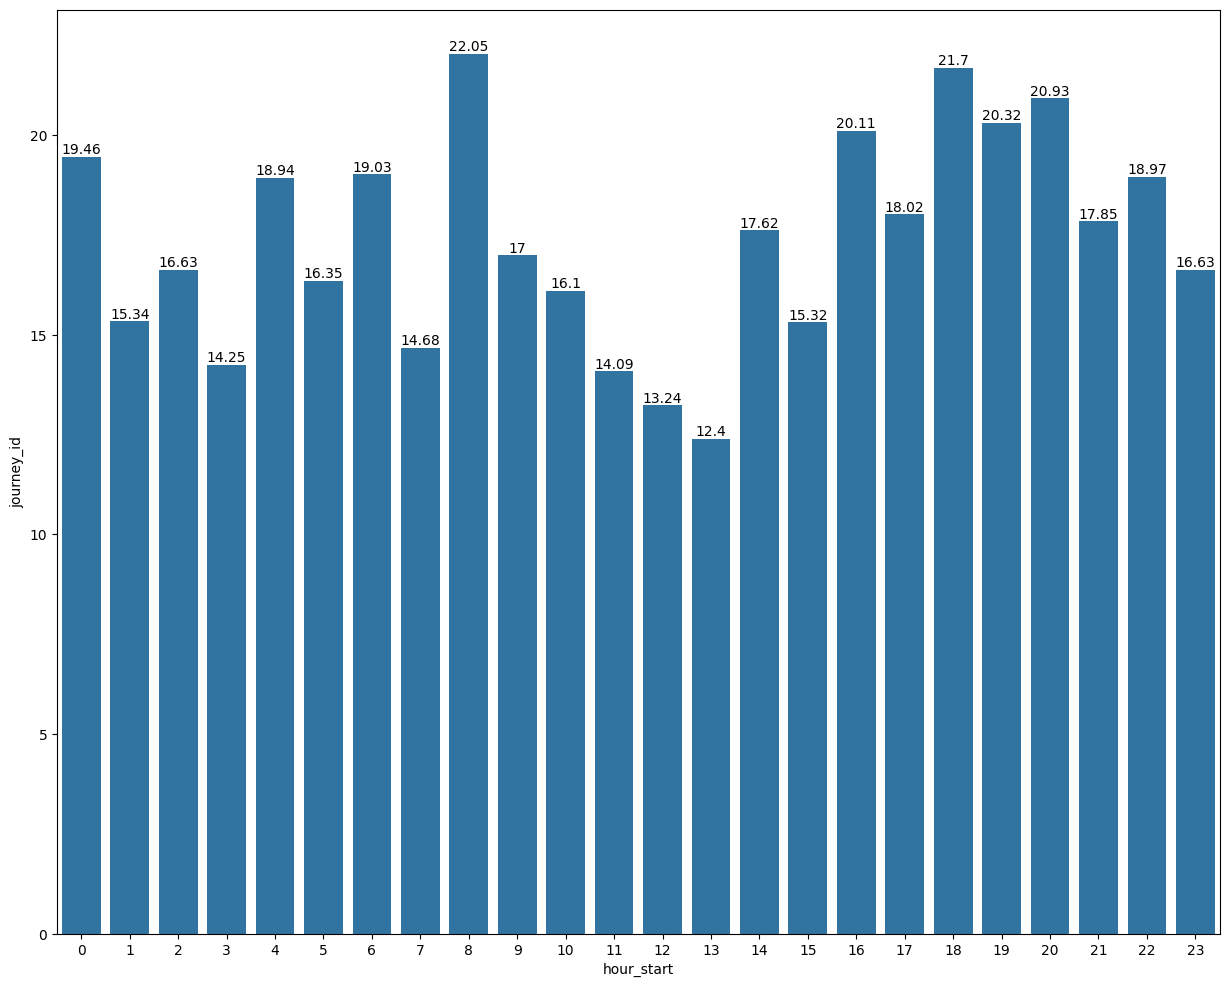

In [253]:
plt.figure(figsize=(15,12))
ax = sns.barplot(cancel_rate, x='hour_start', y='journey_id')
ax.bar_label(ax.containers[0])


In [250]:
cancel_rate

,hour_start,journey_id
0,0,19.46
1,1,15.34
2,2,16.63
3,3,14.25
4,4,18.94
5,5,16.35
6,6,19.03
7,7,14.68
8,8,22.05
9,9,17.00


In [283]:
taxt_score = taxi.dropna(subset=['driver_score', 'rider_score'])
taxt_score = taxt_score.reset_index()
tab_score = round(pd.crosstab(taxt_score['driver_score'], taxt_score['rider_score'], normalize='columns') * 100, 2)

<Axes: xlabel='rider_score', ylabel='driver_score'>

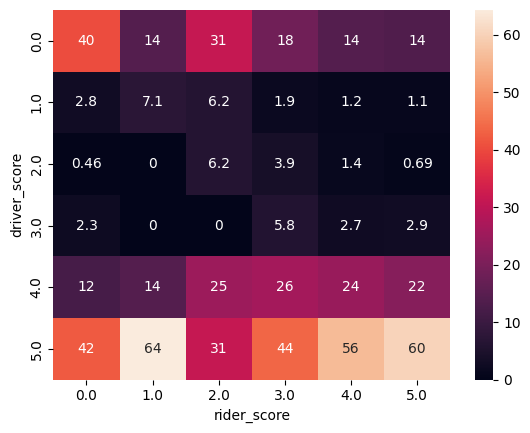

In [288]:
sns.heatmap(tab_score, annot=True)